# AquaInsight — Task 7: Exploratory Data Analysis (EDA)

**Internship Project:** Predicting Water Quality Index for Comprehensive Water Assessment

This notebook is one of the nine independent GitHub deliverables. It can be run separately using the supplied water-quality CSV.

## Step-by-step approach

1. Load the supplied dataset.
2. Perform the task-specific analysis.
3. Display quantitative results.
4. Interpret the results for downstream water-quality modeling.
5. Preserve data for review rather than making unsupported automatic corrections.

In [ ]:
# Common setup — AquaInsight Water Quality Internship

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import mahalanobis

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error

try:
    from rapidfuzz.fuzz import ratio, token_set_ratio
except ImportError:
    raise ImportError("Install RapidFuzz first: pip install rapidfuzz")

possible_paths = [
    Path("Water Quality(1).csv"),
    Path("Water Quality.csv"),
    Path("../data/Water Quality(1).csv"),
    Path("../data/Water Quality.csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place the supplied CSV beside this notebook.")

df = pd.read_csv(DATA_PATH)

print(f"Dataset: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())


# Task 7 — Exploratory Data Analysis (EDA)

### Internship requirement
Perform extensive EDA to identify missing values, understand their patterns, visualize distributions, and assess the nature of missingness.

### Steps
1. Profile missing values and percentages.
2. Examine characteristic frequencies and category cardinality.
3. Visualize major measurement distributions.
4. Inspect measurement units.
5. Examine temporal coverage.
6. Use statistical diagnostics to support conclusions about missingness.


,missing_pct
MonitoringLocationHorizontalAccuracyMeasure,100.000000
MonitoringLocationHorizontalAccuracyUnit,100.000000
ActivityDepthHeightUnit,100.000000
SampleCollectionEquipmentName,100.000000
ActivityEndTime,100.000000
ActivityEndDate,100.000000
MonitoringLocationVerticalUnit,100.000000
MonitoringLocationVerticalMeasure,100.000000
AnalysisStartDate,100.000000
ResultAnalyticalMethodName,100.000000


,records
CharacteristicName,
Specific conductance,8963
pH,8946
"Total Nitrogen, mixed forms",7333
Magnesium,7312
Calcium,7307
Sodium,7300
Organic carbon,7272
Chloride,7250
Sulfate,7240


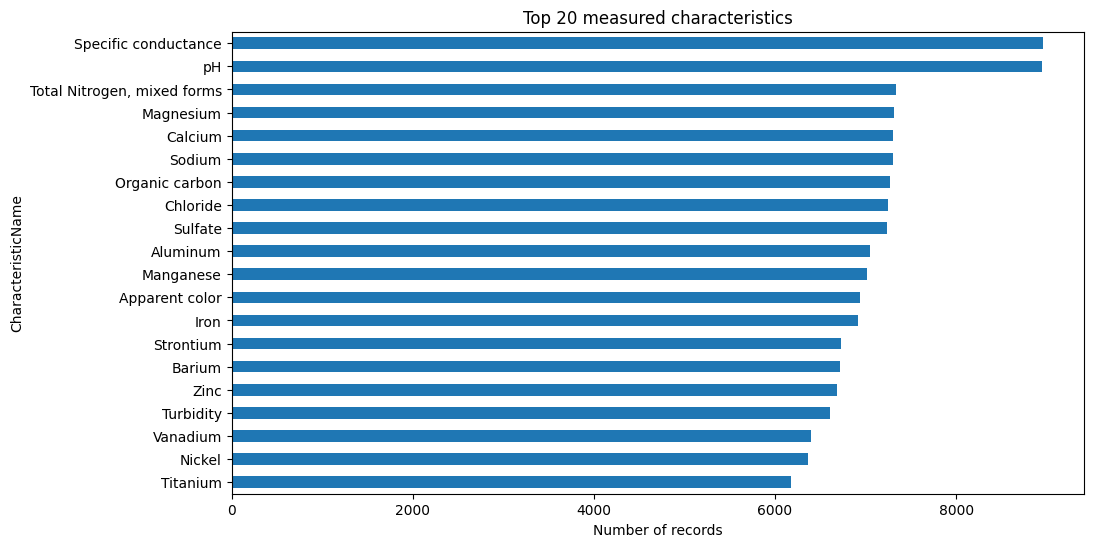

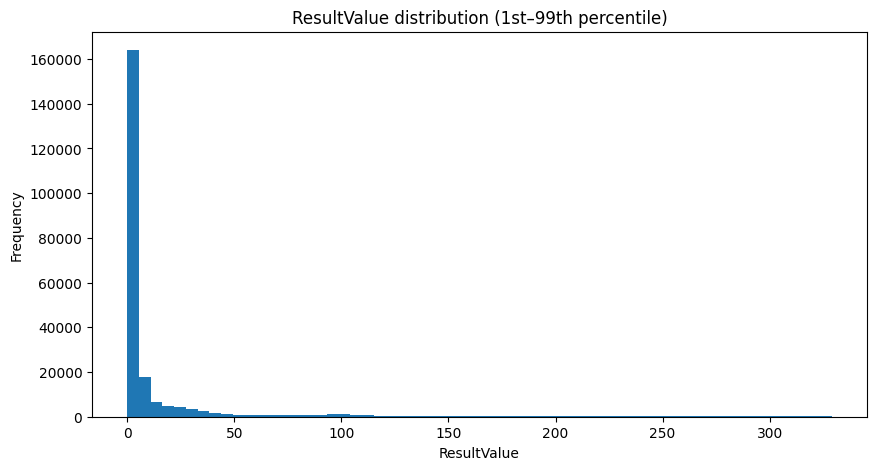

Most common units:


,count
ResultUnit,
ug/L,110660
mg/L,84300
uS/cm,8982
TCU,6954
NTU,4234
JTU,2371
deg C,1853
%,1499
#/100mL,84


In [15]:
# Missingness profile
missing_profile = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)

display(missing_profile.head(20))

# Characteristic frequency
char_counts = df["CharacteristicName"].value_counts().head(20)
display(char_counts.to_frame("records"))

fig = plt.figure(figsize=(11, 6))
char_counts.sort_values().plot(kind="barh")
plt.title("Top 20 measured characteristics")
plt.xlabel("Number of records")
plt.show()

# ResultValue distribution with a robust visual limit
q1, q99 = df["ResultValue"].quantile([0.01, 0.99])
plot_values = df.loc[df["ResultValue"].between(q1, q99), "ResultValue"]

fig = plt.figure(figsize=(10, 5))
plt.hist(plot_values, bins=60)
plt.title("ResultValue distribution (1st–99th percentile)")
plt.xlabel("ResultValue")
plt.ylabel("Frequency")
plt.show()

print("Most common units:")
display(df["ResultUnit"].value_counts().to_frame("count"))


# Missingness heatmap for a manageable sample of columns/rows.
missing_sample = df.sample(min(1000, len(df)), random_state=42).isna()

fig = plt.figure(figsize=(14, 5))
plt.imshow(missing_sample.T, aspect="auto", interpolation="nearest")
plt.yticks(range(len(missing_sample.columns)), missing_sample.columns)
plt.xlabel("Sampled records")
plt.ylabel("Columns")
plt.title("Missingness Matrix — Sample of Records")
plt.show()


## Task 7 — Conclusion

The analysis above completes the requested **Exploratory Data Analysis (EDA)** component of the AquaInsight internship assignment. Results should be interpreted together with domain requirements and the official WQI definition when it becomes available.